# Weight Estimation - Advanced Fine-Tuning and Segmentation

**Author:** Xián Novoa Gutiérrez  
**Project:** Poultry Vision Monitoring  
**Repository:** https://github.com/xiannovoa/poultry-vision-monitoring

## Introduction

In this notebook, we further improve the chicken weight estimation model by refining the transfer learning approach and exploring the impact of input preprocessing through segmentation techniques.

Previous experiments demonstrated that using a pretrained convolutional neural network significantly improves performance (MAE ≈ 50 grams), indicating that transfer learning effectively captures relevant visual features. However, error analysis reveals that prediction performance is not uniform across all weight ranges, suggesting that there is still room for improvement.

To address this, we introduce a more advanced fine-tuning strategy by selectively unfreezing deeper layers of the network and adjusting the learning process to better adapt to the domain-specific characteristics of poultry images.

In addition, we investigate whether removing background information can further improve model performance. For this purpose, we conduct a controlled experiment using a pretrained segmentation model (SAM) to isolate the chicken from the background and evaluate its effect on prediction accuracy.

All models will be evaluated using both MAE (in grams) and relative error, allowing for a consistent comparison with previous approaches while providing a more detailed understanding of model behavior.

## 1. Dataset

https://huggingface.co/datasets/xiannovoa/poultry-weight-dataset

This part is identical to the previous notebooks.

In [1]:
from datasets import load_dataset, Image
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
ROOT = Path.cwd().resolve()

while not (ROOT / "data").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

DATASET_PATH = ROOT / "data/03_final/broiler_weight_dataset"

assert DATASET_PATH.exists(), f"Dataset no encontrado en {DATASET_PATH}"

In [3]:
dataset = load_dataset(
    "csv",
    data_files={"train": str(DATASET_PATH / "labels.csv")}
)

**Important**: The image paths in the CSV are relative (e.g., "images/img_00042.jpg").
We convert them to absolute paths so that the dataset can correctly load images from disk.

In [4]:
def add_full_path(example):
    example["image"] = str(DATASET_PATH / example["image"])
    return example

dataset = dataset.map(add_full_path)

In [5]:
dataset = dataset.cast_column("image", Image())

In [6]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'weight'],
        num_rows: 4761
    })
})


Weight: 1243


(np.float64(-0.5), np.float64(1839.5), np.float64(4079.5), np.float64(-0.5))

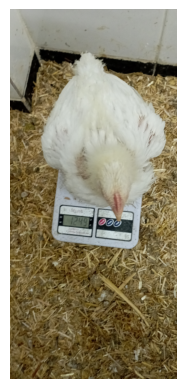

In [7]:
sample = dataset["train"][42]

print("Weight:", sample["weight"])

plt.imshow(sample["image"])
plt.axis("off")

## 2. Data augmentation

In this stage, we refine the augmentation strategy to improve robustness against variations in lighting, orientation, and visual conditions.

Compared to previous notebooks, we introduce slightly stronger transformations to better simulate real-world variability and encourage the model to focus on relevant features rather than superficial patterns.

The validation set remains unchanged to ensure a fair evaluation.

In [8]:
import torchvision.transforms as transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.1,
        hue=0.05
    ),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

## 3. Data Preparation for Training (PyTorch)

We convert the dataset into a PyTorch-compatible format, following the same pipeline used in previous notebooks to ensure consistency across experiments.

This includes:

- applying image transformations  
- creating a custom Dataset  
- preparing data for batching  

Target normalization is retained, as it proved essential for stabilizing training and improving performance in previous experiments.

In [9]:
import torch
from torch.utils.data import Dataset, DataLoader

In [10]:
class NormalizedPoultryDataset(Dataset):
    def __init__(self, hf_dataset, transform=None, mean=0.0, std=1.0):
        self.dataset = hf_dataset
        self.transform = transform
        self.mean = mean
        self.std = std

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        sample = self.dataset[idx]

        image = sample["image"]
        weight = sample["weight"]

        if weight is None:
            raise ValueError(f"Missing weight at index {idx}")

        if self.transform:
            image = self.transform(image)

        weight = (float(weight) - self.mean) / self.std
        weight = torch.tensor(weight, dtype=torch.float32)

        return image, weight

## 4. Train / Validation Split

The same data split and normalization strategy are maintained to ensure a fair comparison with previous models. The following cells and procedures are explained on previous notebooks (available on the repository).

In [11]:
from torch.utils.data import random_split

full_dataset = dataset["train"]

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

# Fix seed for reproducibility
train_subset, val_subset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"Train size: {len(train_subset)}")
print(f"Validation size: {len(val_subset)}")

Train size: 3808
Validation size: 953


In [12]:
import numpy as np

train_weights = [sample["weight"] for sample in train_subset]

mean_weight = np.mean(train_weights)
std_weight = np.std(train_weights)

print(f"Mean weight: {mean_weight:.2f}")
print(f"Std weight: {std_weight:.2f}")

Mean weight: 470.08
Std weight: 391.41


In [13]:
train_dataset = NormalizedPoultryDataset(
    train_subset,
    transform=train_transform, # With data augmentation
    mean=mean_weight,
    std=std_weight
)

val_dataset = NormalizedPoultryDataset(
    val_subset,
    transform=val_transform, # Without data augmentation
    mean=mean_weight,
    std=std_weight
)

In [14]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

## 5. Model (Advanced Fine-Tuning)

We use a pretrained **ResNet18** model and refine the transfer learning strategy.

Instead of only training the final layer, we selectively unfreeze deeper layers (layer3 and layer4) to allow the model to better adapt high-level visual features to the poultry domain.

Earlier layers remain frozen to preserve general visual representations learned from ImageNet.

In [15]:
from torchvision import models
from torchvision.models import ResNet18_Weights
import torch.nn as nn

In [16]:
# Load pretrained ResNet18
model = models.resnet18(weights=ResNet18_Weights.DEFAULT)

# Freeze all layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze deeper layers (layer3 + layer4)
for name, param in model.named_parameters():
    if "layer3" in name or "layer4" in name:
        param.requires_grad = True

# Replace final layer for regression
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 1)

# Move to device
device = torch.device("cpu")
model = model.to(device)

## 6. Training with Validation (Advanced Fine-Tuning)

We train the model using an improved optimization strategy.

Different learning rates are applied to different parts of the network:
- a lower learning rate for pretrained layers (to preserve learned features)
- a higher learning rate for the final layer (to adapt quickly to the regression task)

This allows for a more stable and effective fine-tuning process.

In [17]:
import torch.optim as optim

# Loss
criterion = nn.MSELoss()

# ONLY the trainable parameters
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

num_epochs = 30

for epoch in range(num_epochs):

    # TRAIN
    model.train()
    train_loss = 0.0

    for images, weights in train_loader:
        images = images.to(device)
        weights = weights.to(device)

        optimizer.zero_grad()

        outputs = model(images).squeeze()
        loss = criterion(outputs, weights)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # VALIDATION
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for images, weights in val_loader:
            images = images.to(device)
            weights = weights.to(device)

            outputs = model(images).squeeze()
            loss = criterion(outputs, weights)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    print(f"Epoch [{epoch+1}/{num_epochs}] - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}")

Epoch [1/30] - Train Loss: 0.3475 - Val Loss: 0.1875
Epoch [2/30] - Train Loss: 0.1806 - Val Loss: 0.2674
Epoch [3/30] - Train Loss: 0.1429 - Val Loss: 0.1115
Epoch [4/30] - Train Loss: 0.1250 - Val Loss: 0.0955
Epoch [5/30] - Train Loss: 0.1040 - Val Loss: 0.0739
Epoch [6/30] - Train Loss: 0.0853 - Val Loss: 0.0691
Epoch [7/30] - Train Loss: 0.0912 - Val Loss: 0.0856
Epoch [8/30] - Train Loss: 0.0757 - Val Loss: 0.0640
Epoch [9/30] - Train Loss: 0.0691 - Val Loss: 0.0526
Epoch [10/30] - Train Loss: 0.0626 - Val Loss: 0.0460
Epoch [11/30] - Train Loss: 0.0592 - Val Loss: 0.0961
Epoch [12/30] - Train Loss: 0.0570 - Val Loss: 0.0591
Epoch [13/30] - Train Loss: 0.0492 - Val Loss: 0.0409
Epoch [14/30] - Train Loss: 0.0475 - Val Loss: 0.0419
Epoch [15/30] - Train Loss: 0.0463 - Val Loss: 0.0516
Epoch [16/30] - Train Loss: 0.0381 - Val Loss: 0.0509
Epoch [17/30] - Train Loss: 0.0396 - Val Loss: 0.0474
Epoch [18/30] - Train Loss: 0.0431 - Val Loss: 0.0387
Epoch [19/30] - Train Loss: 0.0369 - 

### Evaluation (MAE + Relative Error)

We evaluate the model using Mean Absolute Error (MAE) in grams, as well as a relative error metric to better reflect performance across different weight ranges.

The relative error is computed as the absolute error divided by the true weight, providing a percentage-based interpretation of the model’s accuracy.

In [18]:
model.eval()

mae = 0.0
relative_error = 0.0

with torch.no_grad():
    for images, weights in val_loader:
        images = images.to(device)
        weights = weights.to(device)

        outputs = model(images).squeeze()

        # Denormalize
        preds = outputs * std_weight + mean_weight
        targets = weights * std_weight + mean_weight

        # MAE
        mae += torch.abs(preds - targets).sum().item()

        # Relative error
        relative_error += (torch.abs(preds - targets) / targets).sum().item()

mae /= len(val_dataset)
relative_error /= len(val_dataset)

print(f"Validation MAE: {mae:.2f} grams")
print(f"Mean Relative Error: {relative_error:.4f} ({relative_error*100:.2f}%)")

Validation MAE: 56.58 grams
Mean Relative Error: 0.1559 (15.59%)


**The results obtained with this configuration are slightly worse than those achieved in *Notebook 03***. Unfreezing an additional block (layer3) and introducing different learning rates did not lead to an improvement, suggesting that increasing model flexibility in this way may negatively affect generalization for this

### Example Prediction

We visualize a prediction and compare it to the real weight.

(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

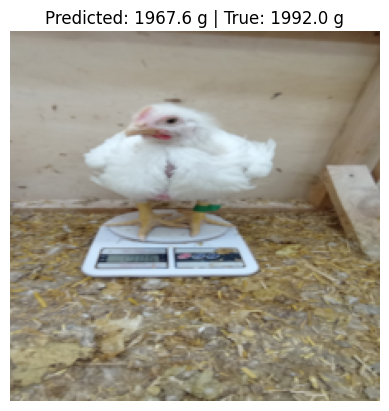

In [19]:
sample = val_dataset[0]

image, weight_norm = sample

model.eval()
with torch.no_grad():
    pred_norm = model(image.unsqueeze(0).to(device)).squeeze().cpu()

pred_weight = pred_norm.item() * std_weight + mean_weight
true_weight = weight_norm.item() * std_weight + mean_weight

img = image.permute(1, 2, 0)

plt.imshow(img)
plt.title(f"Predicted: {pred_weight:.1f} g | True: {true_weight:.1f} g")
plt.axis("off")

## 7. Error Analysis by Weight Range (Histogram)

We analyze the distribution of prediction errors across different weight ranges and compare it with the previous model (*Notebook 03*).

This helps us understand whether the proposed improvements reduce errors consistently or only in specific cases.

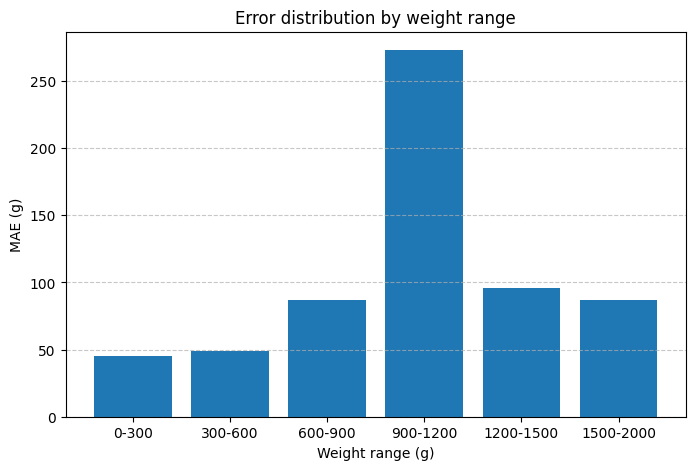

In [20]:
model.eval()

all_targets = []
all_preds = []

with torch.no_grad():
    for images, weights in val_loader:
        images = images.to(device)
        weights = weights.to(device)

        outputs = model(images).squeeze()

        # Denormalize
        preds = outputs * std_weight + mean_weight
        targets = weights * std_weight + mean_weight

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

errors = np.abs(all_preds - all_targets)

# Define bins
bins = [0, 300, 600, 900, 1200, 1500, 2000]
bin_labels = []
mae_per_bin = []

for i in range(len(bins) - 1):
    mask = (all_targets >= bins[i]) & (all_targets < bins[i+1])
    
    if np.sum(mask) > 0:
        mae = np.mean(errors[mask])
        mae_per_bin.append(mae)
        bin_labels.append(f"{bins[i]}-{bins[i+1]}")

# Plot
plt.figure(figsize=(8,5))
plt.bar(bin_labels, mae_per_bin)

plt.xlabel("Weight range (g)")
plt.ylabel("MAE (g)")
plt.title("Error distribution by weight range")

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The error distribution in this configuration shows a less stable behavior compared to *Notebook 03*. While the model maintains reasonable performance for lower weight ranges, the error increases more sharply in the mid-range, with a particularly large spike in the 900–1200g interval.

Compared to the previous model, the error is not only higher in this range but also more irregular across bins, indicating poorer generalization. This suggests that unfreezing additional layers and introducing different learning rates has negatively affected the model’s ability to consistently estimate weight, especially for medium and large chickens.

## 8. Model Saving

We save the trained model to reuse it later without retraining.

In [21]:
torch.save(model.state_dict(), "resnet18_weight_estimation_04.pth")

np.save("val_predictions.npy", all_preds)
np.save("val_targets.npy", all_targets)

## 9. SAM-based Segmentation Experiment

To evaluate the impact of background information, we apply a pretrained segmentation model (SAM) to isolate the chicken from the background.

The goal is to analyze whether removing irrelevant context can improve prediction performance.

In [22]:
# Find project root (same logic as dataset)
ROOT = Path.cwd().resolve()

while not (ROOT / "models").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent

CHECKPOINT_PATH = ROOT / "models" / "sam_vit_b_01ec64.pth"

assert CHECKPOINT_PATH.exists(), f"SAM checkpoint not found at {CHECKPOINT_PATH}"

In [23]:
from segment_anything import sam_model_registry, SamPredictor
import cv2

# Load SAM model
sam = sam_model_registry["vit_b"](checkpoint=str(CHECKPOINT_PATH))
device = torch.device("cpu")
sam.to(device)

predictor = SamPredictor(sam)

In [24]:
# Get sample
image, _ = val_dataset[0]

# Convert to numpy (HWC)
img_np = image.permute(1, 2, 0).numpy()

# SAM expects uint8
img_np = (img_np * 255).astype(np.uint8)

predictor.set_image(img_np)

h, w, _ = img_np.shape

# PROMPT: Bounding Box
input_box = np.array([[
    w * 0.15,
    h * 0.1,
    w * 0.85,
    h * 0.8
]])

masks, scores, logits = predictor.predict(
    box=input_box,
    multimask_output=True,
)

# Select the largest mask instead of relying on the highest score
# This makes the segmentation more robust when SAM outputs multiple candidates
areas = [np.sum(m) for m in masks]
mask = masks[np.argmax(areas)]

# CLEAN MASK
mask = mask.astype(np.uint8) * 255
mask = cv2.medianBlur(mask, 15)
mask = mask > 0

# Fallback: if the segmented area is too small, assume segmentation failed
# and return the original image to avoid introducing noise
if np.sum(mask) < 500:
    segmented = img_np.copy()

else:
    # Crop the image to the bounding box of the mask instead of using a black background
    ys, xs = np.where(mask)
    y_min, y_max = ys.min(), ys.max()
    x_min, x_max = xs.min(), xs.max()

    cropped = img_np[y_min:y_max, x_min:x_max]

    # Resize back to model input size
    segmented = cv2.resize(cropped, (224, 224))

In [25]:
# Apply mask
segmented = img_np.copy()
segmented[~mask] = 0

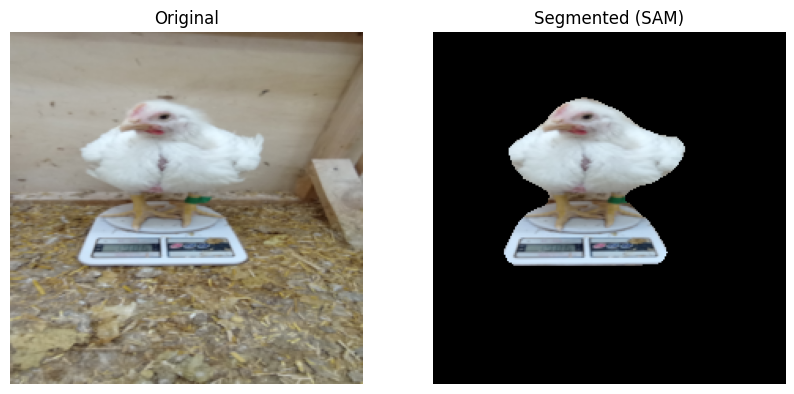

In [26]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(img_np)
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(segmented)
plt.title("Segmented (SAM)")
plt.axis("off")

plt.show()

## 10. SAM-based Dataset and Evaluation

We evaluate the impact of segmentation by applying SAM as a preprocessing step.

Instead of modifying the model architecture, we compare predictions using:
- original images
- SAM-segmented images

This allows us to isolate the effect of removing background information.

In [27]:
def segment_with_sam(image_tensor, predictor):
    img_np = image_tensor.permute(1, 2, 0).numpy()
    img_np = (img_np * 255).astype(np.uint8)

    predictor.set_image(img_np)

    h, w, _ = img_np.shape

    input_box = np.array([[
        w * 0.15,
        h * 0.1,
        w * 0.85,
        h * 0.8
    ]])

    masks, scores, _ = predictor.predict(
        box=input_box,
        multimask_output=True,
    )

    # Select the largest mask instead of relying on the highest score
    areas = [np.sum(m) for m in masks]
    mask = masks[np.argmax(areas)]

    # Fallback: if the segmented area is too small, assume segmentation failed
    # and return the original image to avoid introducing noise
    if np.sum(mask) < 500:
        return image_tensor

    # Crop the image to the bounding box of the mask instead of using a black background
    ys, xs = np.where(mask)
    y_min, y_max = ys.min(), ys.max()
    x_min, x_max = xs.min(), xs.max()

    cropped = img_np[y_min:y_max, x_min:x_max]

    cropped = cv2.resize(cropped, (224, 224))

    cropped = torch.tensor(cropped / 255.0, dtype=torch.float32)
    cropped = cropped.permute(2, 0, 1)

    return cropped

In [28]:
model.eval()

mae_sam = 0.0
relative_error_sam = 0.0

num_samples = 200

with torch.no_grad():
    for i, (image, weight) in enumerate(val_dataset):
        if i >= num_samples:
            break

        # SAM
        image_sam = segment_with_sam(image, predictor).to(device)

        weight = weight.to(device)

        output = model(image_sam.unsqueeze(0)).squeeze()

        # Denormalize
        pred = (output * std_weight + mean_weight).item()
        target = (weight * std_weight + mean_weight).item()

        mae_sam += abs(pred - target)
        relative_error_sam += abs(pred - target) / target

mae_sam /= num_samples
relative_error_sam /= num_samples

print(f"SAM MAE: {mae_sam:.2f} grams")
print(f"SAM Relative Error: {relative_error_sam:.4f} ({relative_error_sam*100:.2f}%)")

SAM MAE: 86.58 grams
SAM Relative Error: 0.2388 (23.88%)
